### Problem Statement

The objective of this project is to analyze Amazon Prime Video content data to extract meaningful insights about content diversity, regional distribution, trends over time, and ratings. This analysis helps understand audience preferences and content strategies.

---

### Hypothesis / Assumptions

- Drama and Comedy are the most common genres on the platform  
- Content production has increased over the years  
- Higher IMDb ratings indicate better content quality  
- Popular shows may not always have high ratings  
- The United States produces the majority of content  

These hypotheses are tested using exploratory data analysis and visualizations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets directly from ZIP
titles = pd.read_csv("titles.csv.zip")
credits = pd.read_csv("credits.csv.zip")

print("Titles Dataset:")
display(titles.head())

print("\nCredits Dataset:")
display(credits.head())

Titles Dataset:


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6



Credits Dataset:


,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [ ]:


# Make copy to avoid modifying original
df = titles.copy()

# Handle missing values
df['imdb_score'] = df['imdb_score'].fillna(df['imdb_score'].mean())
df['imdb_votes'] = df['imdb_votes'].fillna(0)
df['tmdb_score'] = df['tmdb_score'].fillna(df['tmdb_score'].mean())

# Drop rows where title is missing
df.dropna(subset=['title'], inplace=True)

# Convert data types
df['release_year'] = df['release_year'].astype(int)

# Fill categorical missing values
df['age_certification'] = df['age_certification'].fillna("Unknown")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Final check
print("Cleaned Data Shape:", df.shape)
df.head()

Cleaned Data Shape: (9868, 15)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Unknown,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Unknown,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Unknown,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Unknown,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


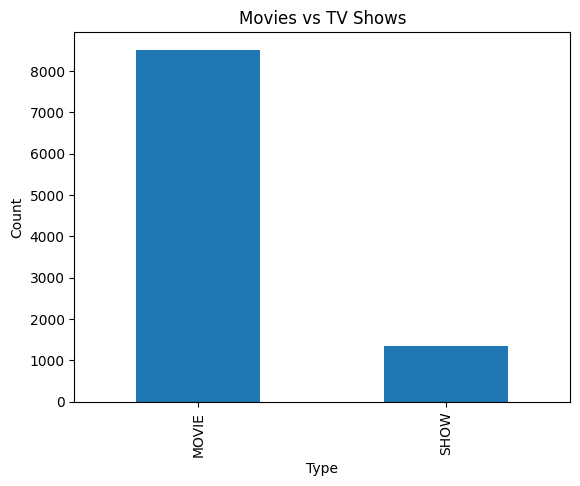

In [ ]:
plt.figure()
df['type'].value_counts().plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

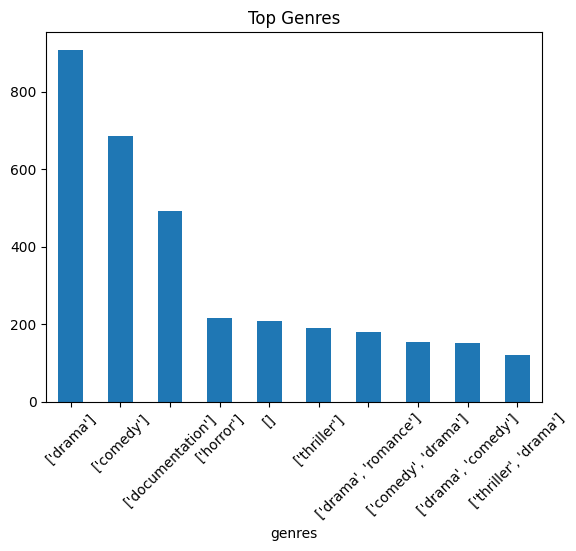

In [ ]:
plt.figure()
df['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.xticks(rotation=45)
plt.show()

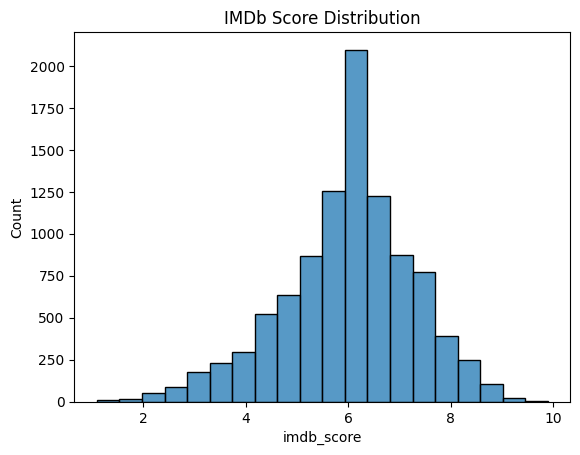

In [ ]:
plt.figure()
sns.histplot(df['imdb_score'], bins=20)
plt.title("IMDb Score Distribution")
plt.show()

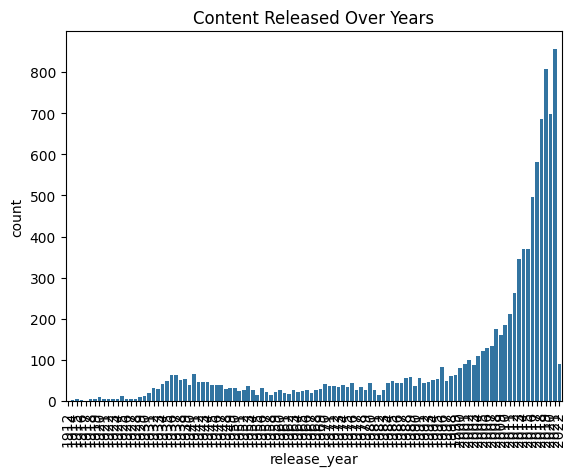

In [ ]:
plt.figure()
sns.countplot(x='release_year', data=df)
plt.xticks(rotation=90)
plt.title("Content Released Over Years")
plt.show()

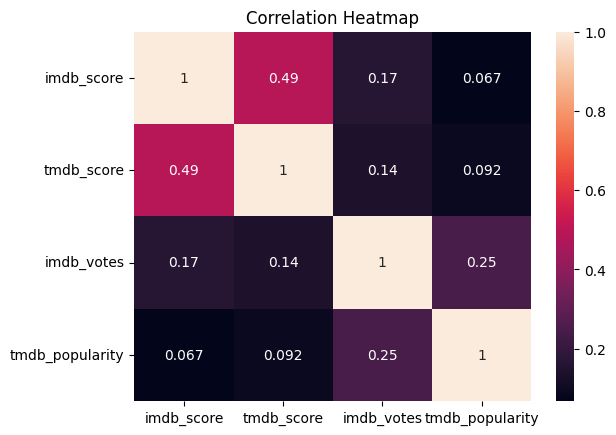

In [ ]:
plt.figure()
sns.heatmap(df[['imdb_score','tmdb_score','imdb_votes','tmdb_popularity']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

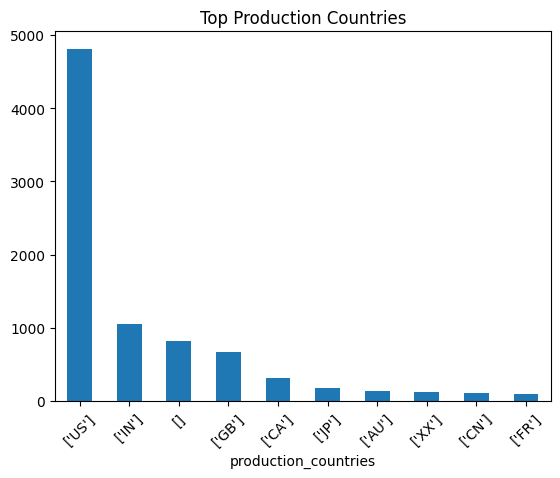

In [ ]:
plt.figure()
df['production_countries'].value_counts().head(10).plot(kind='bar')
plt.title("Top Production Countries")
plt.xticks(rotation=45)
plt.show()

In [ ]:

# Top 10 highest rated shows
top_rated = df.sort_values(by='imdb_score', ascending=False).head(10)
print("Top Rated Shows:")
display(top_rated[['title','imdb_score']])

# Most popular shows
popular = df.sort_values(by='tmdb_popularity', ascending=False).head(10)
print("\nMost Popular Shows:")
display(popular[['title','tmdb_popularity']])

# Top actors
top_actors = credits['name'].value_counts().head(10)
print("\nTop Actors:")
print(top_actors)

# ✅ FIXED HERE
print("\nContent Type Count:")
print(df['type'].value_counts())

# Average IMDb score
print("\nAverage IMDb Score:", df['imdb_score'].mean())

Top Rated Shows:


,title,imdb_score
9135,Pawankhind,9.9
7783,Water Helps the Blood Run,9.7
9108,Couple of Mirrors,9.5
7422,The Chosen,9.4
9423,Tari Sathe,9.4
9573,Pazhagiya Naatkal,9.3
9052,Jai Bhim,9.3
5113,Subaru Launch Control,9.3
8141,Alexander Babu: Alex in Wonderland,9.2
9327,Tom and Jerry,9.2



Most Popular Shows:


,title,tmdb_popularity
8934,All the Old Knives,1437.906
9040,Harina,951.863
9039,The eighth clause,950.986
8964,Hotel Transylvania: Transformania,934.545
7421,Sonic the Hedgehog,893.650
8948,Clifford the Big Red Dog,482.744
9092,Queen of Spades,429.802
9011,Meander,389.431
4099,Suits,356.533
5287,Better Call Saul,352.657



Top Actors:
name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Joseph Kane             41
Gene Autry              40
Sam Newfield            38
Nassar                  37
Charles King            36
Herman Hack             35
George Morrell          34
Name: count, dtype: int64

Content Type Count:
type
MOVIE    8511
SHOW     1357
Name: count, dtype: int64

Average IMDb Score: 5.976520043099992
